# Chapter 4 Companion — Quantum Algorithms

Runnable companions to the worked examples in
[`docs/04_quantum_algorithms`](../docs/04_quantum_algorithms):

- [`05_grover_search.md`](../docs/04_quantum_algorithms/05_grover_search.md)
- [`04_quantum_phase_estimation.md`](../docs/04_quantum_algorithms/04_quantum_phase_estimation.md)
- [`07_hhl_quantum_linear_systems.md`](../docs/04_quantum_algorithms/07_hhl_quantum_linear_systems.md)
- [`08_quantum_cryptography.md`](../docs/04_quantum_algorithms/08_quantum_cryptography.md)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

np.set_printoptions(precision=6, suppress=True)

## Example 1 — Full Grover simulation, `N = 16`, marked item `x* = 5`

*Docs: `05_grover_search.md`, "Worked Example".* With `sin θ = 1/4`
(`θ = arcsin(1/4) ≈ 0.2527`), the optimal iteration count is `k* = ⌊π/4θ⌋ = 3`, with success
probabilities `P(k=2) ≈ 0.908` and `P(k=3) ≈ 0.961`. We build the oracle exactly as the docs
describe (X on the 0-bits of `x*`, a 4-qubit controlled-Z, X back), run the full circuit as a
statevector simulation, and compare against `P = sin²((2k+1)θ)`.

theta = 0.2527 rad, k* = 3 (docs: 0.2527, 3)
k=0:  simulated P(x*=5) = 0.0625,  sin^2((2k+1)θ) = 0.0625
k=1:  simulated P(x*=5) = 0.4727,  sin^2((2k+1)θ) = 0.4727
k=2:  simulated P(x*=5) = 0.9084,  sin^2((2k+1)θ) = 0.9084
k=3:  simulated P(x*=5) = 0.9613,  sin^2((2k+1)θ) = 0.9613
k=4:  simulated P(x*=5) = 0.5817,  sin^2((2k+1)θ) = 0.5817
k=5:  simulated P(x*=5) = 0.1255,  sin^2((2k+1)θ) = 0.1255
k=6:  simulated P(x*=5) = 0.0204,  sin^2((2k+1)θ) = 0.0204
k=7:  simulated P(x*=5) = 0.3649,  sin^2((2k+1)θ) = 0.3649
k=8:  simulated P(x*=5) = 0.8361,  sin^2((2k+1)θ) = 0.8361


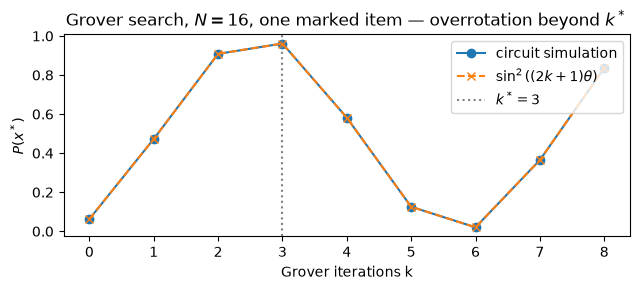

P at k*: 0.9613 (docs: ≈ 0.961); classical expected queries: (N+1)/2 = 8.5


In [2]:
n = 4
N = 2**n
marked = 5                                   # binary 0101

theta = np.arcsin(1 / np.sqrt(N))
k_star = int(np.floor(np.pi / (4 * theta)))
print(f"theta = {theta:.4f} rad, k* = {k_star} (docs: 0.2527, 3)")
assert k_star == 3

def oracle(qc):
    '''Phase-flip |0101> (qubit 0 = least-significant bit).'''
    zeros = [q for q in range(n) if not (marked >> q) & 1]
    qc.x(zeros)
    qc.mcp(np.pi, [0, 1, 2], 3)              # 4-qubit controlled-Z
    qc.x(zeros)

def diffusion(qc):
    qc.h(range(n)); qc.x(range(n))
    qc.mcp(np.pi, [0, 1, 2], 3)
    qc.x(range(n)); qc.h(range(n))

def grover_probability(k):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for _ in range(k):
        oracle(qc)
        diffusion(qc)
    return np.abs(Statevector(qc).data[marked])**2

ks = np.arange(0, 9)
p_sim = np.array([grover_probability(k) for k in ks])
p_theory = np.sin((2*ks + 1) * theta)**2
for k in ks:
    print(f"k={k}:  simulated P(x*={marked}) = {p_sim[k]:.4f},  sin^2((2k+1)θ) = {p_theory[k]:.4f}")
assert np.allclose(p_sim, p_theory, atol=1e-9)
assert np.isclose(p_sim[2], 0.908, atol=5e-4) and np.isclose(p_sim[3], 0.961, atol=5e-4)

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(ks, p_sim, "o-", label="circuit simulation")
ax.plot(ks, p_theory, "x--", label=r"$\sin^2((2k+1)\theta)$")
ax.axvline(k_star, color="gray", ls=":", label=r"$k^*=3$")
ax.set_xlabel("Grover iterations k"); ax.set_ylabel(r"$P(x^*)$")
ax.set_title(r"Grover search, $N=16$, one marked item — overrotation beyond $k^*$")
ax.legend(); fig.tight_layout(); plt.show()
print(f"P at k*: {p_sim[3]:.4f} (docs: ≈ 0.961); classical expected queries: (N+1)/2 = 8.5")

## Example 2 — Quantum phase estimation of `φ = 1/4` (`U = S`, eigenstate `|1⟩`)

*Docs: `04_quantum_phase_estimation.md`, "Worked Example".* `S|1⟩ = e^{2πi/4}|1⟩`, so
`φ = 1/4` — a dyadic rational, hence with `n = 3` ancillas QPE must output
`j* = 2ⁿφ = 2 = 010₂` **with probability 1**. We build the circuit (H layer, controlled
`S^{2^j}` powers, inverse QFT) and confirm; then we re-run with `U = T` (`φ = 1/8`) and
`n = 2` ancillas, reproducing Exercise 2's non-dyadic outcome distribution
`{0.427, 0.427, 0.073, 0.073}`.

In [3]:
from qiskit.circuit.library import QFTGate

def qpe_distribution(phase_gate_angle, n_anc):
    '''QPE on U = diag(1, e^{i angle}) with eigenstate |1>. Returns outcome pmf over j.'''
    qc = QuantumCircuit(n_anc + 1)
    qc.x(n_anc)                              # eigenstate |1> on the target (last qubit)
    qc.h(range(n_anc))
    for j in range(n_anc):                   # ancilla j controls U^{2^j}
        qc.cp(phase_gate_angle * 2**j, j, n_anc)
    qc.append(QFTGate(n_anc).inverse(), range(n_anc))   # inverse QFT decodes the phase
    sv = Statevector(qc)
    probs = np.zeros(2**n_anc)
    for idx, amp in enumerate(sv.data):
        j = idx & (2**n_anc - 1)             # ancilla register bits
        probs[j] += abs(amp)**2
    return probs

# U = S: phi = 1/4, n = 3  ->  j* = 2 with certainty
probs_S = qpe_distribution(np.pi/2, 3)
print("QPE(U=S, n=3) outcome distribution:", probs_S.round(6))
j_star = int(np.argmax(probs_S))
print(f"outcome j* = {j_star} = {j_star:03b}₂, recovered phase = {j_star}/8 = {j_star/8}")
assert j_star == 2 and np.isclose(probs_S[2], 1.0)

# U = T: phi = 1/8, n = 2  ->  split between j=0 and j=1 (Exercise 2)
probs_T = qpe_distribution(np.pi/4, 2)
print("\nQPE(U=T, n=2) outcome distribution:", probs_T.round(4),
      " (docs: 0.427, 0.427, 0.073, 0.073)")
assert np.allclose(probs_T, [0.4267767, 0.4267767, 0.0732233, 0.0732233], atol=1e-4)
print("worst-case bound 4/pi^2 =", 4/np.pi**2, "≤ best-estimate prob", probs_T[0].round(4), "✓")

QPE(U=S, n=3) outcome distribution: [0. 0. 1. 0. 0. 0. 0. 0.]
outcome j* = 2 = 010₂, recovered phase = 2/8 = 0.25

QPE(U=T, n=2) outcome distribution: [0.4268 0.4268 0.0732 0.0732]  (docs: 0.427, 0.427, 0.073, 0.073)
worst-case bound 4/pi^2 = 0.4052847345693511 ≤ best-estimate prob 0.4268 ✓


## Example 3 — HHL on the pedagogical 2×2 system

*Docs: `07_hhl_quantum_linear_systems.md`, "Worked Example".*
`A = [[1,−1/3],[−1/3,1]]`, `|b⟩ = |0⟩`. Eigenpairs: `A|+⟩ = (2/3)|+⟩`, `A|−⟩ = (4/3)|−⟩`,
`κ = 2`. With `t = 3π/4`, a 2-qubit clock stores `λ̃₁ = 1`, `λ̃₂ = 2` exactly; the controlled
rotation with `C = 1` and post-selection on the ancilla `|1⟩` gives `P(1) = 5/8` and
`|x⟩ = (3|0⟩+|1⟩)/√10` — matching the classical solution `x = (9/8, 3/8)`.
We emulate each algorithm step numerically.

In [4]:
A = np.array([[1, -1/3], [-1/3, 1]])
b = np.array([1.0, 0.0])

lam, U = np.linalg.eigh(A)
print("eigenvalues:", lam, " (docs: 2/3, 4/3);  kappa =", lam[1]/lam[0])
assert np.allclose(lam, [2/3, 4/3])

beta = U.T @ b                                # expansion of |b> in the eigenbasis
print("beta_j = <u_j|b> :", beta, " (both ±1/√2)")

# Step 1 (QPE): clock values lambda_tilde = lambda * t * 2^n / (2 pi), t = 3pi/4, n = 2
t, n_clock = 3*np.pi/4, 2
lam_tilde = lam * t * 2**n_clock / (2*np.pi)
print("clock values lambda~ :", lam_tilde, " (docs: 1, 2 — exact integers)")
assert np.allclose(lam_tilde, [1, 2])

# Step 2 (controlled rotation) + Step 4 (post-select ancilla |1>)
C = 1.0
amp_1 = beta * C / lam_tilde                  # amplitude on the ancilla-|1> branch
P1 = np.sum(np.abs(amp_1)**2)
print(f"post-selection probability P(1) = {P1} (docs: 5/8 = {5/8})")
assert np.isclose(P1, 5/8)

x_state_eig = amp_1 / np.sqrt(P1)             # normalized solution state, eigenbasis
x_state = U @ x_state_eig                     # back to the computational basis
if x_state[0] < 0: x_state = -x_state
print("|x> =", x_state, " (docs: (3,1)/√10 =", np.array([3, 1])/np.sqrt(10), ")")
assert np.allclose(np.abs(x_state), np.array([3, 1])/np.sqrt(10))

# classical check
x_classical = np.linalg.solve(A, b)
print("classical x =", x_classical, " (docs: (9/8, 3/8));  normalized:",
      x_classical/np.linalg.norm(x_classical))
assert np.allclose(x_classical, [9/8, 3/8])
print("measurement probabilities of |x>: ", (np.abs(x_state)**2).round(4), " (docs: 0.9 / 0.1)")

eigenvalues: [0.666667 1.333333]  (docs: 2/3, 4/3);  kappa = 2.0
beta_j = <u_j|b> : [-0.707107 -0.707107]  (both ±1/√2)
clock values lambda~ : [1. 2.]  (docs: 1, 2 — exact integers)
post-selection probability P(1) = 0.6249999999999999 (docs: 5/8 = 0.625)
|x> = [0.948683 0.316228]  (docs: (3,1)/√10 = [0.948683 0.316228] )
classical x = [1.125 0.375]  (docs: (9/8, 3/8));  normalized: [0.948683 0.316228]
measurement probabilities of |x>:  [0.9 0.1]  (docs: 0.9 / 0.1)


## Example 4 — BB84 intercept-resend: QBER Monte Carlo

*Docs: `08_quantum_cryptography.md`.* Full intercept-resend in a random BB84 basis causes
exactly **25 % QBER** on the sifted key while giving Eve `I(A:E) = 0.5` bits/sifted bit;
attacking only a fraction `η` scales the QBER to `η/4` (Exercise 2: `QBER = 5% ⟹ η = 0.2`).
The secure-key rate is `r = 1 − 2H₂(Q)`, positive only below `Q ≈ 11.0 %`
(Exercise 4: `r(1%) = 0.838`, `r(5%) = 0.427`, `r(8%) = 0.196`).
We Monte-Carlo the protocol qubit-by-qubit.

full attack     sifted =  99950  QBER = 0.2511 (theory 0.2500)   Eve knows 0.499 bits/sifted (theory 0.500)
20% of pulses   sifted =  99922  QBER = 0.0495 (theory 0.0500)   Eve knows 0.100 bits/sifted (theory 0.100)
no Eve          sifted =  99831  QBER = 0.0000 (theory 0.0000)   Eve knows 0.000 bits/sifted (theory 0.000)


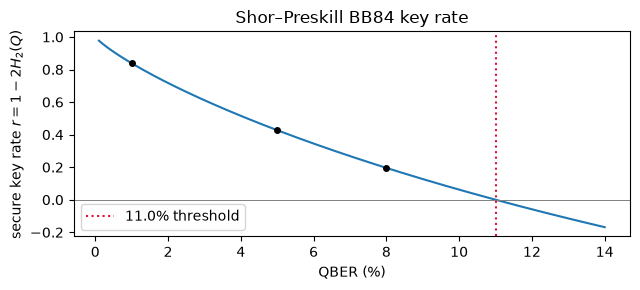

r(1%), r(5%), r(8%) = [np.float64(0.838), np.float64(0.427), np.float64(0.196)]  (docs: 0.838, 0.427, 0.196)
k needed for detection except with prob 1e-6: 49  (docs: 49)


In [5]:
rng = np.random.default_rng(2024)

def bb84_run(n_pulses, eve_fraction):
    '''Simulate BB84 with intercept-resend on a random fraction of pulses.
    Bases: 0 = Z, 1 = X. Returns (sifted key length, errors, eve_known_bits).'''
    alice_bits  = rng.integers(0, 2, n_pulses)
    alice_bases = rng.integers(0, 2, n_pulses)
    bob_bases   = rng.integers(0, 2, n_pulses)
    attacked    = rng.random(n_pulses) < eve_fraction
    eve_bases   = rng.integers(0, 2, n_pulses)

    # state Eve resends (or Alice's state if untouched), described by (basis, bit)
    chan_basis, chan_bit = alice_bases.copy(), alice_bits.copy()
    eve_bits = np.full(n_pulses, -1)
    hit = np.where(attacked)[0]
    same = eve_bases[hit] == alice_bases[hit]
    # matching basis: Eve reads Alice's bit; wrong basis: fair coin
    eve_bits[hit[same]] = alice_bits[hit[same]]
    eve_bits[hit[~same]] = rng.integers(0, 2, (~same).sum())
    chan_basis[hit] = eve_bases[hit]
    chan_bit[hit]   = eve_bits[hit]

    # Bob measures: same basis as channel state -> deterministic; else fair coin
    bob_bits = np.where(bob_bases == chan_basis,
                        chan_bit, rng.integers(0, 2, n_pulses))

    sift = alice_bases == bob_bases
    errors = (alice_bits != bob_bits) & sift
    eve_known = sift & attacked & (eve_bases == alice_bases)
    return sift.sum(), errors.sum(), eve_known.sum()

def H2(q):
    return 0.0 if q in (0, 1) else -q*np.log2(q) - (1-q)*np.log2(1-q)

n_pulses = 200_000
for eta, label in [(1.0, "full attack"), (0.2, "20% of pulses"), (0.0, "no Eve")]:
    n_sift, n_err, n_known = bb84_run(n_pulses, eta)
    qber = n_err / n_sift
    print(f"{label:15s} sifted = {n_sift:6d}  QBER = {qber:.4f} "
          f"(theory {eta/4:.4f})   Eve knows {n_known/n_sift:.3f} bits/sifted "
          f"(theory {eta/2:.3f})")
    assert abs(qber - eta/4) < 0.005

qs = np.linspace(0.001, 0.14, 300)
rates = np.array([1 - 2*H2(q) for q in qs])
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(qs*100, rates)
ax.axhline(0, color="gray", lw=0.7)
ax.axvline(11.0, color="crimson", ls=":", label="11.0% threshold")
for q in (0.01, 0.05, 0.08):
    ax.plot(q*100, 1 - 2*H2(q), "ko", ms=4)
ax.set_xlabel("QBER (%)"); ax.set_ylabel(r"secure key rate $r = 1-2H_2(Q)$")
ax.set_title("Shor–Preskill BB84 key rate")
ax.legend(); fig.tight_layout(); plt.show()
print("r(1%), r(5%), r(8%) =", [round(1 - 2*H2(q), 3) for q in (0.01, 0.05, 0.08)],
      " (docs: 0.838, 0.427, 0.196)")
assert np.isclose(1 - 2*H2(0.05), 0.427, atol=1.5e-3)

# detection probability: P(Eve undetected after k compared bits) = (3/4)^k  (Exercise 1)
k = np.arange(0, 60)
print("k needed for detection except with prob 1e-6:",
      int(np.ceil(np.log(1e-6)/np.log(0.75))), " (docs: 49)")